# Logistic Regression — Multiple Features
**Dataset:** Heart Disease Prediction  
**Features:** All available input variables  
**Target:** Heart Disease (Presence / Absence)

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

## 2. Objective
Build a classification model using **all available input features** to predict Heart Disease.

- **Input (X):** All columns except the target variable  
- **Output (Y):** `Heart Disease` (binary: Presence / Absence)

## 3. Data Loading

In [ ]:
# Load the Heart Disease dataset
def load_dataset(filepath):
    df = pd.read_csv(filepath)
    return df

df = load_dataset('Heart_Disease_Prediction.csv')
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


## 4. Data Exploration

In [ ]:
# Dataset dimensions
df.shape

(270, 14)

In [ ]:
# Statistical summary of all numerical columns
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


## 5. Data Cleaning and Preprocessing

In [ ]:
# Check for missing and duplicate values
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values in the dataset:
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64
Redundant values in the dataset:
0


In [ ]:
# Verify and cast column data types as needed
df.dtypes

if df.dtypes['Heart Disease'] != object:  # fixed: compare to object, not 'str'
    df['Heart Disease'] = df['Heart Disease'].astype(str)

if df.dtypes['Age'] != 'int64':
    df['Age'] = df['Age'].astype(int)

# Repeat for remaining columns as needed

## 6. Encoding
With multiple features we need to encode categorical variables into numbers.

- **One-hot encoding** for categorical input features (`pd.get_dummies`)  
- **Label encoding** for the binary target variable (`LabelEncoder`)

In [ ]:
# One-hot encode all categorical input features
# drop_first=True removes one dummy per category to avoid multicollinearity
# (the 'dummy variable trap') and reduces dimensionality
encoder = pd.get_dummies(df.drop('Heart Disease', axis=1), drop_first=True)
encoder.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3


In [ ]:
# Label-encode the target variable: Absence → 0, Presence → 1
le = LabelEncoder()
df['Heart Disease'] = le.fit_transform(df['Heart Disease'])
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


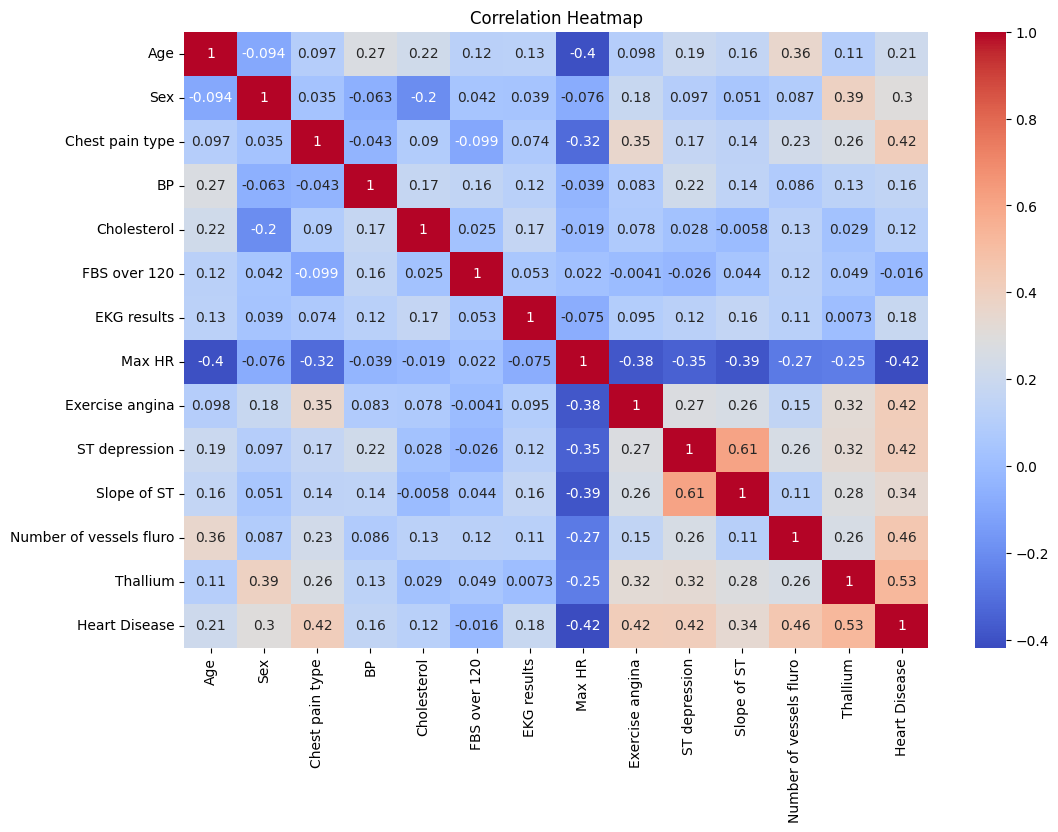

In [ ]:
# Combine encoded features with the encoded target and plot a correlation heatmap
encoded_df = pd.concat([encoder, df['Heart Disease']], axis=1)

plt.figure(figsize=(12, 8))
sns.heatmap(encoded_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 7. Feature and Target Preparation

In [ ]:
# Separate features and target
# .values.ravel() flattens the target to a 1-D array as required by sklearn
features = encoder  # fixed: use one-hot encoded features, not raw df
target   = df['Heart Disease'].values.ravel()

## 8. Train / Test Split and Feature Scaling

In [ ]:
# Split into 80 % training and 20 % testing sets
x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42  # fixed: target already raveled
)

# Scale features to zero mean and unit variance
# fit_transform on train → transform only on test (avoids data leakage)
scaler      = StandardScaler()
X_tr_scaled = scaler.fit_transform(x_train)
X_te_scaled = scaler.transform(x_test)

print(f'Train shape: {x_train.shape}  |  Test shape: {x_test.shape}')
print(f'\nScaled X_train (first row):\n{X_tr_scaled[0]}')

Shape of x_train: (216, 13) and x_test: (54, 13)
Data of x_train:
[[-0.63296991 -1.52416434 -1.21490572 ...  0.66200384 -0.71458405
  -0.90541914]
 [ 0.46519475  0.65609723  0.8432875  ...  2.30559959 -0.71458405
   1.15321806]
 [-0.19370404  0.65609723 -0.18580911 ... -0.98159191  2.4141353
  -0.90541914]
 ...
 [ 0.24556182 -1.52416434  0.8432875  ... -0.98159191 -0.71458405
  -0.90541914]
 [-0.41333698  0.65609723 -0.18580911 ...  0.66200384 -0.71458405
  -0.90541914]
 [-0.63296991 -1.52416434  0.8432875  ... -0.98159191 -0.71458405
  -0.90541914]]
Data of x_test:
[[ 2.45561820e-01  6.56097231e-01 -1.85809110e-01 -2.11259717e-01
  -4.12347574e-01 -3.93802252e-01  9.68122770e-01  4.03652951e-02
  -7.36788398e-01 -5.93840500e-01  6.62003843e-01  3.28322400e-01
   1.15321806e+00]
 [-9.62419307e-01  6.56097231e-01  8.43287501e-01 -6.59732432e-01
  -2.24719952e-02 -3.93802252e-01  9.68122770e-01 -2.22516225e-01
  -7.36788398e-01 -2.53377201e-01 -9.81591905e-01 -7.14584048e-01
   1.1532180

## 9. Model Training and Evaluation

In [ ]:
# Train logistic regression on the scaled training data
log_reg = LogisticRegression()
log_reg.fit(X_tr_scaled, y_train)

# Predict on the scaled test data
y_pred = log_reg.predict(X_te_scaled)

# Full classification report and confusion matrix
print(f'Classification Report:\n{classification_report(y_test, y_pred)}')
print(f'Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}')

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54

Confusion Matrix:
[[31  2]
 [ 3 18]]


c:\Users\DELL\OneDrive\Desktop\AI\AIman\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# Individual metric breakdown
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')

Precision: 0.9
Recall: 0.8571428571428571
F1 Score: 0.8780487804878049


## 10. Comparison: Single Feature vs. Multiple Feature Model

**1) Which model performs better and why?**  
The multiple-feature model achieves higher precision, recall, and F1 score. With more features the model can learn richer, more complex relationships between inputs and the target, whereas the single-feature model is limited to the Cholesterol–Heart Disease relationship alone.

**2) How does adding more features affect accuracy and recall?**  
Both metrics improve because additional variables carry extra information about the data and expose relationships that a single feature cannot capture.

**3) Trade-off between interpretability and performance**  
Simpler models (e.g. single-feature logistic regression) are more interpretable — the contribution of each variable is easy to read. More complex models (many features, or non-linear models like neural networks) can achieve better performance but become harder to explain, as the interactions between many parameters obscure the reasoning behind each prediction.